In [60]:
import torch
from torch import nn
from d2l import torch as d2l
import sys
import os
import math
import time
import json
import pandas as pd

# 将上级目录添加到 sys.path，以便导入 d2l_utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import d2l_utils

# 批量大小和时间步数
batch_size, num_steps = 32, 35
# 使用本地 d2l_utils 中的 load_data_time_machine 加载时光机器数据集
train_iter, vocab = d2l_utils.load_data_time_machine(batch_size, num_steps)

In [61]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [62]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [63]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        # 修改：将 tanh 替换为 relu
        H_tilda = torch.relu((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)


In [64]:
# 引入 RNN.ipynb 中定义的辅助函数和类
from torch.nn import functional as F

class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return torch.tensor(self.times).cumsum(dim=0)

class RNNModelScratch:
    """从零开始实现的 RNN 模型类"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        # 初始化参数
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state = init_state
        self.forward_fn = forward_fn

    def __call__(self, X, state):
        # 将输入 X 转置并进行 one-hot 编码，转换为浮点数
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        # 调用前向传播函数
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        # 初始化隐藏状态
        return self.init_state(batch_size, self.num_hiddens, device)

def predict_ch8(prefix, num_preds, net, vocab, device):
    """在 `prefix` 后面生成新字符"""
    # 初始化隐藏状态，batch_size 为 1
    state = net.begin_state(batch_size=1, device=device)
    # 将 prefix 的第一个字符转换为索引
    outputs = [vocab[prefix[0]]]
    # 定义一个 lambda 函数，用于获取最新的输入（上一个预测的字符）
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    # 预热期：使用 prefix 中的字符更新隐藏状态，但不记录输出
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    # 预测期：生成 num_preds 个新字符
    for _ in range(num_preds):
        # 使用上一个字符和当前状态进行预测
        y, state = net(get_input(), state)
        # 将预测结果（概率最大的索引）添加到 outputs
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    # 将索引转换回字符并拼接成字符串
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def grad_clipping(net, theta):
    """梯度裁剪，防止梯度爆炸"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    # 计算所有参数梯度的 L2 范数
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    # 如果范数超过阈值 theta，则按比例缩小梯度
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """训练网络一个迭代周期"""
    state, timer = None, Timer()
    metric = d2l.Accumulator(2)  # 累加器：训练损失之和，词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 如果是第一次迭代或使用随机抽样，初始化状态
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            # 否则，分离状态以切断计算图，防止梯度反向传播到之前的批次
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        # 将标签 Y 转置并展平
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        # 前向传播
        y_hat, state = net(X, state)
        # 计算损失
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            # 因为已经调用了 mean 函数，所以 batch_size 传 1
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    # 返回困惑度（perplexity）和每秒处理的词元数
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def save_and_compare_results(current_ppl, current_speed, activation, filename="training_history.json"):
    """保存当前训练结果，并与历史记录进行比较"""
    current_result = {
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "activation": activation,
        "perplexity": current_ppl,
        "speed": current_speed
    }

    history = []
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as f:
                history = json.load(f)
        except json.JSONDecodeError:
            print("Warning: Could not read history file. Starting new history.")

    # 保存当前结果
    history.append(current_result)
    with open(filename, 'w') as f:
        json.dump(history, f, indent=4)
    print(f"Result saved to {filename}")

def show_history(filename="training_history.json"):
    """读取并展示历史训练记录"""
    if not os.path.exists(filename):
        print("No history file found.")
        return

    try:
        with open(filename, 'r') as f:
            history = json.load(f)
    except json.JSONDecodeError:
        print("Error reading history file.")
        return

    if not history:
        print("History is empty.")
        return

    # 使用 Pandas DataFrame 展示，更加美观
    df = pd.DataFrame(history)
    # 调整列顺序
    cols = ['timestamp', 'activation', 'perplexity', 'speed']
    # 确保列存在
    cols = [c for c in cols if c in df.columns]
    df = df[cols]

    print("\n" + "="*50)
    print("Training History Summary")
    print("="*50)
    print(df.to_string(index=False))
    print("="*50)

    # 找出最佳成绩
    best_idx = df['perplexity'].idxmin()
    best_run = df.iloc[best_idx]
    print(f"\nBest Run:\n{best_run.to_string()}")
    print("="*50 + "\n")

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False, activation="relu"):
    """训练模型"""
    loss = nn.CrossEntropyLoss()
    # 动画绘制器，用于实时显示训练进度
    animator = d2l_utils.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    # 定义预测函数，用于在训练过程中观察生成效果
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # 训练循环
    ppl, speed = 0.0, 0.0
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        # 每 10 个 epoch 打印一次预测结果并更新图表
        if (epoch + 1) % 10 == 0:
            # 注意：animator.add 会调用 clear_output，所以这里的 print 可能会被清除
            # 我们只在最后打印详细信息
            animator.add(epoch + 1, [ppl])

    # 训练结束后，打印最终结果，这次不会被清除
    print(f'\nFinal Result: perplexity {ppl:.1f}, {speed:.1f} tokens/sec on {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

    # 保存结果
    save_and_compare_results(ppl, speed, activation)
    # 展示历史记录
    show_history()


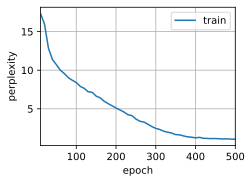

In [65]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
# 使用本地定义的 RNNModelScratch
model = RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
# 使用本地定义的 train_ch8，并指定 activation 为 "relu"
train_ch8(model, train_iter, vocab, lr, num_epochs, device, activation="relu")

In [67]:
# 如果您想单独查看历史记录，可以运行这个单元格
show_history()


Training History Summary
          timestamp activation  perplexity         speed
2026-03-03 11:48:49        NaN    1.129627  91030.115323
2026-03-03 11:50:45       relu    1.060926  97244.374798
2026-03-03 14:57:04       relu    1.058178 114279.609428
2026-03-03 14:58:32       tanh    1.056189 116250.398545
2026-03-03 15:00:26       relu    1.056571 111271.218386

Best Run:
timestamp     2026-03-03 14:58:32
activation                   tanh
perplexity               1.056189
speed               116250.398545

